# Stochastic subgradient descent

## Part 1: Algorithm implementation

Here we try to define the problem:

Given a RV si follow a distribution with probability P over Si, find the minimal x* in X for the Expectation of function f: X x Si -> R

### Function Definition

Here we first define the mapping of RV si to a L-lipschitz convex function f(x)

1. We assume that the L-lipschitz convex function is the maximum of a set of affine functinos ax + b
2. As in the assumption, we need the slope of affine have absolute value smaller than L (|a| < L)
3. The function should have a constant mapping of random variable si to all parameters including count, slope and intersection of affine functions.


For the subgradient
- Check if x lands in intersection by finding the maximum value of all affine evaluates
- If so, take any gradient within the range of intersecting affine, which is achieved by the affine combination of the slopes

In [56]:
from typing import List, Optional
import numpy as np

class WeightMapping:
    def __init__(self, d: int, q: int, m: int):
        assert d > 0 and q > 0 and m > 0, "invalid d, q, m: Must larger than 0"
        self.A = (np.random.random(size=(q, d)) * 10)
        self.v = np.random.random(size=(m)) - 0.5
        self.B = (np.random.random(size=(m, q)) - 0.5)

        # Store copy
        self.d = d
        self.q = q
        self.m = m


In [57]:

class Realization:
    """Realization of f given fixed rv"""
    def __init__(self, weight_map: WeightMapping, si: np.ndarray):
        assert si.shape[0] == weight_map.q
        self.weight_map = weight_map

        # set function weights
        self._weights = np.sin(np.outer(self.weight_map.v, si) @ self.weight_map.A)
        self._bias = (weight_map.B @ si)   
        self.si = si

        # keep lipschitz
        # for a_i in self._weights:
        #     norm = np.linalg.norm(a_i)
        #     if norm > L:
        #         a_i = (a_i / norm) * L
    

    def __str__(self):
        return f"""si = {self.si}\na = {self._weights}\nb = {self._bias}\n
        """
    
       
    def __call__(self, x: np.ndarray):
        """evaluate f(x)"""
        assert x.shape[0] == self.weight_map.d, print(f"Invalid dimension: {x.shape}, d: {self.weight_map.d}")
        values = self._weights @ x + self._bias
        return np.max(values)
    
    def subgrad(self, x: np.ndarray):
        assert x.shape[0] == self.weight_map.d, print(f"Invalid dimension: {x.shape}, d: {self.weight_map.d}")

        
        values = (self._weights @ x) + self._bias
        max_val = max(values)
        # tolerance matching
        is_active = np.isclose(values, max_val, atol=1e-9)
        active_weights = self._weights[is_active]
        active_count = len(active_weights)
        
        # If only one affine is active, return that as grad
        if active_count == 1:
            return active_weights[0]
        
        # In case of more than one active count
        # get some affine combination of all grad
        # Shape: k,d.T @ k, => d,
        lambdas = np.random.dirichlet([1.0] * active_count)
        return active_weights.T @ lambdas
    



### Testing of realization

Here we check the behaviour of our generating function

1. Generate suitable si
2. Run the realization 
3. Plot all affine 
4. Since the realization is implemeented with a call, we just call the function with the realization and plot the function evaluate using the red line
5. In a constant linespace, we also plot their respective subgradient. Most likely the intersection is not exactly on the line space, but there are some small chance that there are some blue line that is not the gray affine, thats the random subgradient

si = [0.21530667 0.38773138 0.83294546 0.53507082 0.92227607]
a = [[-0.82473531]
 [-0.97613756]
 [-0.95992569]
 [-0.40560873]
 [ 0.99057823]
 [-0.91707034]
 [-0.27869843]
 [-0.49989977]
 [-0.99223985]
 [ 0.48395126]]
b = [-0.58032186 -0.09882293  0.74449675 -0.05352406 -0.26139386  0.45573967
  0.69074877  0.17061395 -0.10597714  0.04944791]

        


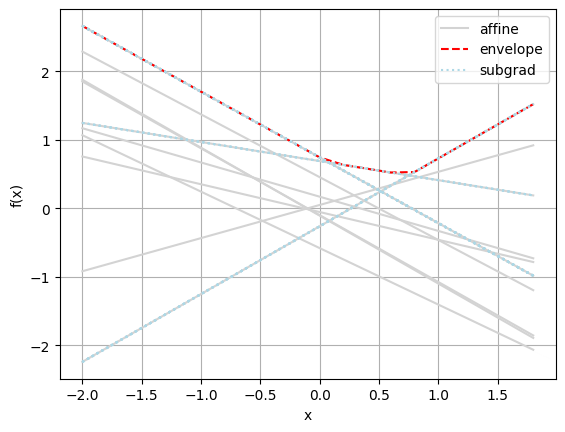

In [58]:
import matplotlib.pyplot as plt

## As a sample, we show graph with d=1
d = 1
q = 5
m = 10
weight_mappping = WeightMapping(d, q, m)
si = np.random.random(size=(q))
realization1 = Realization(weight_mappping, si)
print(realization1)



# Plot the affine functions
weights = realization1._weights
bias = realization1._bias
x = np.arange(-2, 2, 0.2)
for i, (a, b) in enumerate(zip(weights, bias)):
    y = [a*x_i + b for x_i in x]
    label = "affine" if i == 0 else ""
    plt.plot(x, y, color="lightgrey", label=label)
    

# Plot the convex envelop
fx = [realization1(np.array([x_i])) for x_i in x]
plt.plot(x, fx, color="red", linestyle="--", label="envelope")

# Test subgradient
# NOTE: It is quite rare for the point to directly coincide with intersections 
# (where gradient become subgradient)
# We can randomize more attempts to get the extra line
for i, x_i in enumerate(x):
    x_pt = np.array([x_i])
    f_x = realization1(x_pt)
    subgrad = realization1.subgrad(x_pt)
    y_support = subgrad * (x - x_i) + f_x
    label = "subgrad" if i == 0 else ""
    plt.plot(x, y_support, color='lightblue', linestyle="dotted", label=label)
    
 
# Styling
# plt.title("Visualiation of one realization in 1D")
plt.ylabel("f(x)")
plt.xlabel("x")
plt.grid()
plt.legend()
plt.savefig("affine.png")

### Main training loop

In [59]:
from dataclasses import dataclass
from typing import Callable


def lr(t: int) -> float:
    return 1 / np.sqrt(t + 1)
    # return 1


@dataclass
class SsgdResult:
    grad_hist: List[np.ndarray]
    x_hist: List[np.ndarray]
    x_mean_hist: np.ndarray


def ssgd(
    d: int,
    T: int,
    lr: Callable[[int], float],
    si: np.ndarray,
    weight_map: WeightMapping,
    x0: Optional[np.ndarray] = None
):
    """given a predecided si (T, d), run ssgd to find minizer of expected f"""
    assert (
        si.shape[0] == T and si.shape[1] == weight_map.q and len(si.shape) == 2
    ), f"Si needs to be set with shape T, q. Shape of si: {si.shape}"

    # Generate init point
    if x0 is not None:
        x = x0
    else:
        x = np.random.rand(d)

    grad_hist = []
    x_hist = []

    lr_agg = 0
    lr_x_agg = 0
    x_mean_hist = []

    for t in range(T):
        # Use given si to create realization object
        realization = Realization(weight_map, si[t])

        # Compute subgradient at current x
        g = realization.subgrad(x)

        # Store for monitoring
        grad_hist.append(g)

        # Update step
        x = x - lr(t) * g
        x_hist.append(x)

        # Track x_mean
        lr_agg += lr(t)
        lr_x_agg += lr(t) * x

        x_mean = lr_x_agg / lr_agg
        x_mean_hist.append(x_mean)

    return SsgdResult(
        grad_hist=grad_hist, x_hist=x_hist, x_mean_hist=np.array(x_mean_hist)
    )

### Show convergence

Here we want to find the convergence of x_mean in expected value of f(x_mean) over random variable si

Since we dont have the close form for f(si), we use out sample to simulate the expected value

1. Run ssgd to get the x_mean history
2. Generate a new set of function from the same distribution
3. Evaluate the values of x_mean against out_sample functions

In [60]:
def evaluation(x_mean_hist: np.ndarray, si: np.ndarray, weight_map: WeightMapping) -> List[List[float]]:
    """Output a matrix with shape (#si, #x_mean_hist)"""
    
    # We have obtained x_mean list during training already
    # Here we want to know, for each x_mean at iter k, what is expectation of f_mean - f*
    # We find the expectation of taking mean of f(x_mean) - f(x*)

    f_x_mean = []
    for si_i in si:
        # Reconstruct the realizations as in ssgd
        realization = Realization(weight_map, si_i)
        vals = [realization(x_mean_i) for x_mean_i in x_mean_hist]
        f_x_mean.append(vals)
    return f_x_mean

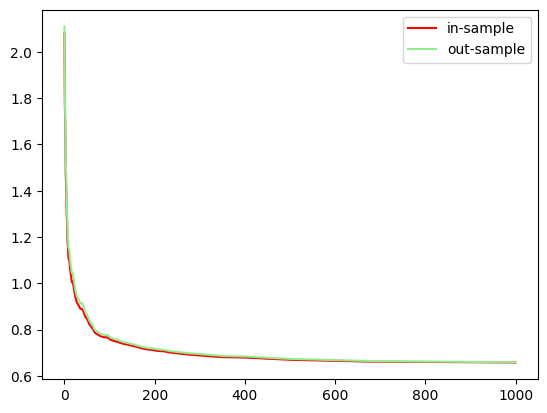

In [61]:
in_sample_count = 1000
out_sample_count = 500
d = 10
q = 10
m = 10
L = 5.0
T = 1000

# Global mapping for realization
weight_map = WeightMapping(d, q, m)

si = np.random.random(size=(in_sample_count, d))
si2 = np.random.random(size=(out_sample_count, d))


result: SsgdResult = ssgd(d, T, lr, si, weight_map)
# This is the main variable that shows convergence
# x_mean_hist shape: (T, d)
x_mean_hist = result.x_mean_hist

x_mean_in = evaluation(x_mean_hist, si, weight_map)
x_mean_eval = evaluation(x_mean_hist, si2, weight_map)

# We find the mean of each step
avg_x_in = np.array(x_mean_in).mean(axis=0)
avg_x_eval = np.array(x_mean_eval).mean(axis=0)

# Plot graph
# plt.title("x_mean convergence")
plt.plot(avg_x_in, color="red", label="in-sample")
plt.plot(avg_x_eval, color="lightgreen", label="out-sample")
plt.legend()
plt.savefig("convergence.png")



### More distribution to test

Here we try to introduce more distribution of xi other than uniform distribution.

                     poisson       exp_1       exp_3       chi_1       chi_5  \
converged_k       499.000000  499.000000  499.000000  499.000000  499.000000   
estimation_error    2.217203    2.320228    5.243079    2.725328    7.052463   

                      normal  
converged_k       499.000000  
estimation_error    1.770554  


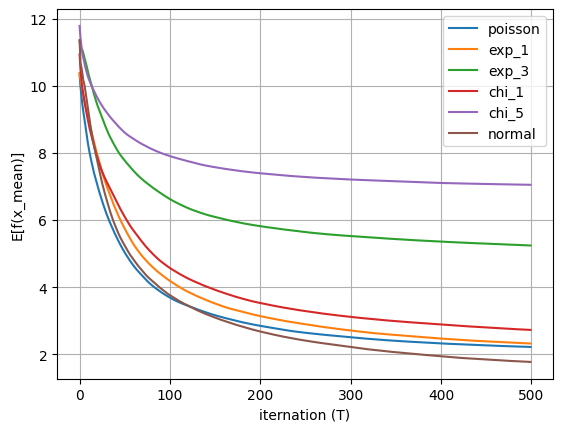

In [62]:
import pandas as pd

## Select different type of distribution
q = 10
d = 10
m = 10
T = 500
si_poisson = np.random.poisson(1, size=(T, q))
si_exp_1 = np.random.exponential(1, size=(T, q))
si_exp_3 = np.random.exponential(3, size=(T, q))
si_chi_1 = np.random.chisquare(1, size=(T, q))
si_chi_5 = np.random.chisquare(5, size=(T, q))
si_normal = np.random.random(size=(T, q))

si_catagory = {"poisson": si_poisson, "exp_1": si_exp_1, "exp_3": si_exp_3, "chi_1": si_chi_1, "chi_5": si_chi_5, "normal": si_normal}

# setup controlled variables
x0 = np.random.random(size=(d)) * 5 # Use same init value, but scale it larger to see convergent rate
weight_mapping = WeightMapping(d, q, m)

converge_statistics = {}

# Eval Loop
for k, v in si_catagory.items():
    result = ssgd(d, T, lr, v, weight_map, x0=x0.copy())
    eval = evaluation(result.x_mean_hist, v, weight_map)
    avg = np.array(eval).mean(axis=0)

    # We as well find the converged iteration and the final estimation error
    epsilon = 1e-5
    for i in range(1, len(avg)):
        if abs(avg[i] - avg[i - 1]) <= epsilon:
            converge_statistics[k] = {
                "converged_k": i,
                "estimation_error": avg[i]
            }
            plt.plot(avg, label=k)
            break

    if i == len(avg) - 1:
        converge_statistics[k] = {
                "converged_k": i,
                "estimation_error": avg[i]
            }
        plt.plot(avg, label=k)
        


# plt.title("Convergent rate of different si distribution")
plt.xlabel("iternation (T)")
plt.ylabel("E[f(x_mean)]")
plt.legend()
plt.grid()
plt.savefig("distribution.png")

# Wrap into panas
df = pd.DataFrame(converge_statistics)
print(df)



    

## Conclusion

In the graph we can see the convergence of Expected value in terms of x_mean, which is in O(1/sqrt(t))

This behaviour is generalizable for the same distribution of function in terms of si.